In [143]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,recall_score,accuracy_score,precision_score,f1_score, classification_report, ConfusionMatrixDisplay
import pickle


In [144]:
df = pd.read_csv('../data/raw/09-k-means-housing.csv')
df.shape
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### 1-Limpieza Inicial

In [145]:
df = df.drop(["HouseAge","AveRooms","AveBedrms","Population","AveOccup","MedHouseVal"],axis=1)
df.drop_duplicates(inplace=True)
df.shape


(20635, 3)

### 2-Split

In [146]:
X_train, X_test = train_test_split(df, test_size=0.2,random_state=42)
X_train, X_test

(       MedInc  Latitude  Longitude
 19985  3.1453     36.20    -119.31
 11235  5.2384     33.81    -117.96
 2271   3.5542     36.78    -119.80
 8660   4.3594     33.85    -118.39
 6250   3.4722     34.04    -117.98
 ...       ...       ...        ...
 11288  5.2370     33.80    -117.95
 11968  1.9052     34.00    -117.41
 5392   3.1827     34.04    -118.37
 860    5.7192     37.58    -121.96
 15799  2.8458     37.76    -122.43
 
 [16508 rows x 3 columns],
        MedInc  Latitude  Longitude
 8572   8.4680     33.90    -118.41
 1712   3.9722     37.97    -122.32
 15916  3.4583     37.74    -122.42
 5196   1.6625     33.94    -118.27
 13583  1.5156     34.13    -117.29
 ...       ...       ...        ...
 8470   4.2596     33.91    -118.31
 2144   2.7850     36.77    -119.76
 3665   3.5521     34.22    -118.37
 7111   4.4954     33.90    -118.02
 16604  3.3472     35.63    -120.72
 
 [4127 rows x 3 columns])

### Cocnlusiones

Split antes de escalado para evitar data leakage

### 3-Escalado

In [147]:
scaler = RobustScaler()
scaler_train = scaler.fit_transform(X_train)
scaler_test = scaler.transform(X_test)
scaler_train, scaler_test


(array([[-0.1765489 ,  0.51187335, -0.21315789],
        [ 0.77610514, -0.11873351,  0.14210526],
        [ 0.00955795,  0.66490765, -0.34210526],
        ...,
        [-0.15952665, -0.05804749,  0.03421053],
        [ 0.99493656,  0.87598945, -0.91052632],
        [-0.3128634 ,  0.92348285, -1.03421053]], shape=(16508, 3)),
 array([[ 2.24602606, -0.09498681,  0.02368421],
        [ 0.19980657,  0.97889182, -1.00526316],
        [-0.03409   ,  0.9182058 , -1.03157895],
        ...,
        [ 0.00860215, -0.01055409,  0.03421053],
        [ 0.43793594, -0.09498681,  0.12631579],
        [-0.08465608,  0.36147757, -0.58421053]], shape=(4127, 3)))

#### Conclusiones

-Utilizamos RobustScaler ya que usa mediana y rango intercuartílico(IQR) lo que hace que sea resistente a outliers

In [148]:
fig = px.scatter_3d(df,
              x="Latitude",
              y="Longitude",
              z="MedInc",
              color="MedInc")
fig.update_layout(
    scene=dict(
        xaxis=dict(showgrid=True, gridcolor="lightgrey", zeroline=True),
        yaxis=dict(showgrid=True, gridcolor="lightgrey", zeroline=True),
        zaxis=dict(showgrid=True, gridcolor="lightgrey", zeroline=True)
    )

)
fig.update_traces(marker=dict(size=3))
fig.show()


### 4-Método del codo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

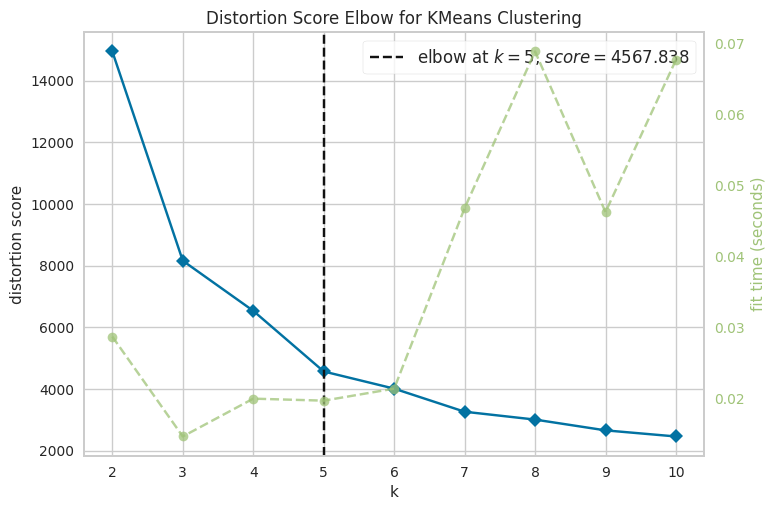

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [149]:
k_means_visual = KMeans(random_state=18)
elbow_visualizer = KElbowVisualizer(k_means_visual, k=(2,11))
elbow_visualizer.fit(scaler_train)
elbow_visualizer.show()



### Conclusiones

-Aplicamos el modelo kMeans pero con el objetivo de visualizar  el número optimo de clusters mediante el metodo codo(Elbow Method)
-Cluster: Grupo natural de observaciones similares(Patrones)

### 5-Modelado

In [150]:
k_means = KMeans(n_clusters=6, random_state=18)
k_means.fit(scaler_train)

,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,18
,copy_x,True
,algorithm,'lloyd'


### Conclusiones

-Entrenamos el modelo con los parametros que nos devolvió el metodo del codo anteriormente y obtenemos los cluster(etiquetas) en un solo paso(fit_predict)

-Aunque el método del codo aplicado sobre el conjunto de entrenamiento sugiere utilizar 5 clusters, en este proyecto se ha definido el número de clusters en 6, siguiendo las instrucciones del enunciado.

### 6-Predicciones

In [151]:
train_clusters = k_means.predict(scaler_train)
test_clusters = k_means.predict(scaler_test)
train_clusters, test_clusters


(array([2, 0, 5, ..., 2, 1, 3], shape=(16508,), dtype=int32),
 array([4, 5, 5, ..., 2, 0, 5], shape=(4127,), dtype=int32))

### 7-Añadir cluster al df

In [152]:
X_train["cluster"] = train_clusters
X_test["cluster"] = test_clusters

df_scaled = scaler.transform(df)
df["cluster"] = k_means.predict(df_scaled)

### 8-Visualización de clusters

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

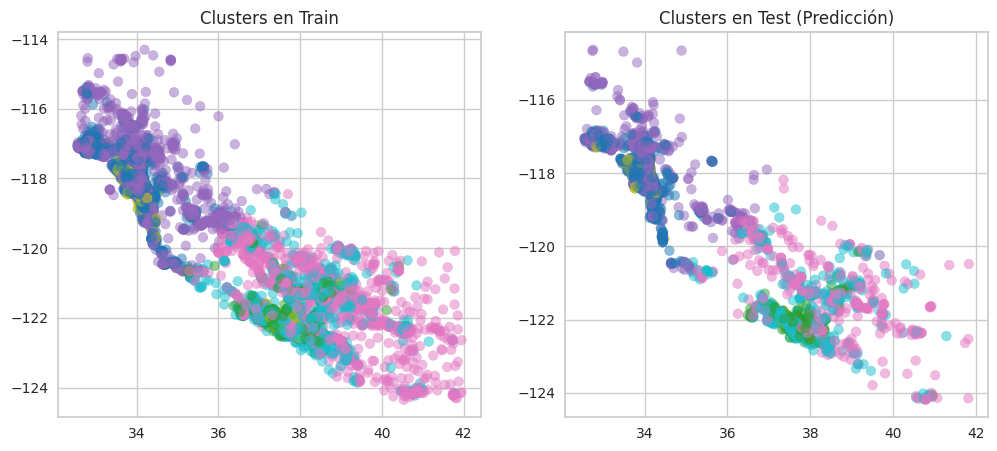

In [153]:
plt.figure(figsize=(12, 5))

# Train
plt.subplot(1, 2, 1)
plt.scatter(X_train["Latitude"], X_train["Longitude"], c=train_clusters, cmap='tab10', alpha=0.5)
plt.title('Clusters en Train')

# Test
plt.subplot(1, 2, 2)
plt.scatter(X_test["Latitude"], X_test["Longitude"], c=test_clusters, cmap='tab10', alpha=0.5)
plt.title('Clusters en Test (Predicción)')

plt.show()

### Conclusiones

-comparación visual entre los clusters del conjunto de entrenamiento y los del conjunto de prueba.

### 9-Mapeado

In [154]:
ingreso_medio_por_cluster = X_train.groupby('cluster')['MedInc'].mean().sort_index()
ingreso_medio_por_cluster

cluster
0     5.158423
1     6.114050
2     2.703908
3     2.230976
4    10.135017
5     3.894801
Name: MedInc, dtype: float64

### Conclusiones

-Indexamos los cluster obtenidos y le asignamos como valor la media de ingresos(valores transofrmados)

In [155]:
ingresos = {
    0: "Ingresos medios",
    1: "Ingresos altos",
    2: "Ingresos bajos",
    3: "Ingresos bajos",
    4: "Ingresos altos",
    5: "Ingresos medios"}
X_train["Ingresos"] = X_train["cluster"].map(ingresos)
X_test["Ingresos"] = X_test["cluster"].map(ingresos)
df["Ingresos"] = df["cluster"].map(ingresos)


### Conclusiones

-Mapeamos para asignar un valor mas amigable a cada cluster segun los ingresos


### 7-Entrenamiento y objetivo

In [156]:
X = df.drop(["cluster","Ingresos"], axis=1)
y = df["cluster"]

### 8-Split

In [157]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y)
X_train,X_test,y_train,y_test

(       MedInc  Latitude  Longitude
 8096   3.6923     33.81    -118.21
 19622  4.0000     37.33    -121.29
 1569   7.9393     37.74    -121.98
 11480  5.1630     33.72    -118.03
 7614   3.0417     33.88    -118.23
 ...       ...       ...        ...
 10243  6.4514     33.91    -117.86
 12043  6.8089     33.88    -117.44
 16824  5.1550     37.63    -122.49
 369    3.8913     37.75    -122.15
 17570  4.8519     37.32    -121.94
 
 [16508 rows x 3 columns],
        MedInc  Latitude  Longitude
 18420  5.5875     37.26    -121.83
 13950  3.9375     34.24    -117.07
 16892  4.4000     37.58    -122.37
 7291   1.2059     33.98    -118.22
 20308  4.0222     34.19    -119.13
 ...       ...       ...        ...
 19302  4.7422     38.39    -122.82
 19469  2.2336     37.68    -120.99
 302    1.8407     37.76    -122.18
 7075   6.2924     33.93    -117.98
 7631   3.5094     33.84    -118.29
 
 [4127 rows x 3 columns],
 8096     2
 19622    5
 1569     1
 11480    0
 7614     2
         ..
 10243 

### 9-Modelo(Supervisado)

In [158]:
xgbc_optimized = XGBClassifier()
xgbc_optimized.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### 10-Predicción

In [159]:
y_predict_train = xgbc_optimized.predict(X_train)
y_predict_test = xgbc_optimized.predict(X_test)
y_predict_train,y_predict_test

(array([2, 5, 1, ..., 1, 5, 5], shape=(16508,)),
 array([1, 2, 5, ..., 3, 0, 2], shape=(4127,)))

### 11-Obtención de Métricas

In [160]:
def get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train, average='weighted'):
    metrics_train = (accuracy_score(y_train, y_predict_train),
                     f1_score(y_train, y_predict_train, average=average),
                     precision_score(y_train, y_predict_train, average=average),
                     recall_score(y_train, y_predict_train, average=average))
    metrics_test = (accuracy_score(y_test, y_predict_test),
                    f1_score(y_test, y_predict_test, average=average),
                    precision_score(y_test, y_predict_test, average=average),
                    recall_score(y_test, y_predict_test, average=average))
    return pd.DataFrame(data=[metrics_train, metrics_test],
                        columns=['Accuracy', 'F1 Score', 'Precision', 'Recall'],
                        index=['Train set', 'Test set'])

result = get_classifier_metrics(y_predict_test, y_test, y_predict_train, y_train)
result

,Accuracy,F1 Score,Precision,Recall
Train set,0.999939,0.999939,0.999939,0.999939
Test set,0.991519,0.991519,0.991547,0.991519


### Conclusiones

-utilizamos Boosting(XGBClassifier) por su gran precision y capacidad de generalización

### 12-Metricas detalladas

[[ 886    1    5    0    3    2]
 [   0  325    0    0    0    0]
 [   0    0 1376    4    0    1]
 [   0    0    0  686    0    5]
 [   1    2    0    0  131    0]
 [   0    1    3    7    0  688]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       897
           1       0.99      1.00      0.99       325
           2       0.99      1.00      1.00      1381
           3       0.98      0.99      0.99       691
           4       0.98      0.98      0.98       134
           5       0.99      0.98      0.99       699

    accuracy                           0.99      4127
   macro avg       0.99      0.99      0.99      4127
weighted avg       0.99      0.99      0.99      4127



findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

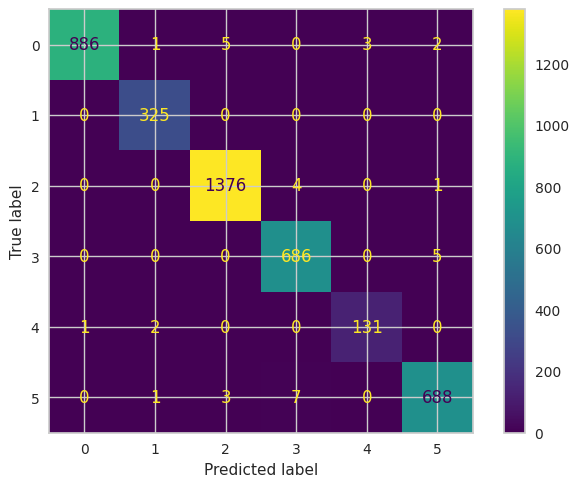

In [161]:
print(confusion_matrix(y_test,y_predict_test))
print(classification_report(y_test,y_predict_test))
ConfusionMatrixDisplay.from_estimator(xgbc_optimized,X_test, y_test)

### 13-Guardado

In [162]:
# Guardar K-Means
with open('../models/kmeans_housing.pkl', 'wb') as f:
    pickle.dump(k_means, f)

# Guardar XGBClassifier
with open('../models/xgb_housing.pkl', 'wb') as f:
    pickle.dump(xgbc_optimized, f)

# Guardar Escalador
with open('../models/scaler_housing.pkl', 'wb') as f:
    pickle.dump(scaler, f)